In [84]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt

from custom_functions import *

save_format = "svg"

# Load data

## Bulk gastruloid
For this analysis, we will only retain the samples from the 72h and the initial condition at 48h, immediately before Chiron treatment.

In [85]:
df_gastruloid = pd.read_csv("../data/wnt_nodal_rnaseq/counts_chir_act_project.csv",index_col=0).T
df_gastruloid = df_gastruloid.loc[:,~df_gastruloid.columns.duplicated()].copy() #Remove potentially duplicated genes names (very few and irrelevant genes are duplicated)
df_gastruloid_metadata = pd.read_csv("../data/wnt_nodal_rnaseq/chir_act_metadata.csv",index_col=1)

#Retain only samples of interest
df_gastruloid = df_gastruloid.loc[[(("CHIR" in i) and ("72h" in i)) or ("48h_" in i) for i in df_gastruloid.index.values]]
df_gastruloid_metadata = df_gastruloid_metadata.loc[[(("CHIR" in i) and ("72h" in i)) or ("48h_" in i) for i in df_gastruloid_metadata.index.values]]

In [86]:
# Step 1: Drop the unwanted '_2' replicate row
if '72h-3μM-CHIR_2' in df_gastruloid.index:
    df_gastruloid = df_gastruloid.drop(index='72h-3μM-CHIR_2')

# Step 2: Rename '_5' replicate to '_2'
df_gastruloid = df_gastruloid.rename(index={'72h-3μM-CHIR_5': '72h-3μM-CHIR_2'})

# Step 3: Reorder index
order = ['48h_1', '48h_2', '48h_3',
         '72h-0.5μM-CHIR_1', '72h-0.5μM-CHIR_2', '72h-0.5μM-CHIR_3',
         '72h-3μM-CHIR_1', '72h-3μM-CHIR_2', '72h-3μM-CHIR_3',
         '72h-20μM-CHIR_1','72h-20μM-CHIR_2', '72h-20μM-CHIR_3']

df_gastruloid = df_gastruloid.loc[order, :]


## Pseudobulk mouse

From the generated pseudobulk mouse dataset, we keep all points except from one sample at E7.25, which had some sampling problems (refer to the original paper) and the mixed samples.

In [87]:
# df_embryo = pd.read_csv("../data/pseudobulk/pijuan_sala_pseudobulk.csv",index_col=0).T
# df_embryo = df_embryo.loc[:,~df_embryo.columns.duplicated()].copy() #Remove potentially duplicated genes names (very few and irrelevant genes are duplicated)

# #Remove samples
# df_embryo = df_embryo[df_embryo.index.values != "S26_E7.25"]
# df_embryo = df_embryo[df_embryo.index.values != "mixed_gastrulation_21"]
# df_embryo = df_embryo[df_embryo.index.values != "mixed_gastrulation_22"]
# df_embryo.sort_index(inplace=True)

# df_embryo_metadata = pd.DataFrame({"Condition":[i[:-2] for i in df_embryo.index.values]},index=df_embryo.index.values)

In [88]:
#embryo
df_embryo = pd.read_excel('../data/pseudobulk/mouse_embryonic_pseudobulk_by_stage.xlsx', sheet_name='Sheet 1')
df_embryo['gene_symbol'].replace('T','Tbxt', inplace=True)
df_embryo = df_embryo.set_index("gene_symbol")
df_embryo.drop(columns='gene_ID', inplace=True)
df_embryo = df_embryo.T
df_embryo.head()

/tmp/ipykernel_14561/1757289291.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_embryo['gene_symbol'].replace('T','Tbxt', inplace=True)


gene_symbol,Xkr4,Gm1992,Gm37381,Rp1,Sox17,Gm37323,Mrpl15,Lypla1,Gm37988,Tcea1,...,AC125149.1,AC125149.2,AC125149.4,AC234645.1,AC168977.2,AC168977.1,AC149090.1,DHRSX,Vmn2r122,CAAA01147332.1
E6.5,2,0,0,0,19,0,13424,2299,1,3335,...,0,0,0,0,0,16,538,731,0,3
E6.75,0,0,0,0,88,0,4653,657,0,1136,...,0,0,0,0,0,0,158,275,0,1
E7.0,7,0,0,2,5670,0,62154,10830,7,15400,...,0,0,0,0,0,11,2081,3942,0,11
E7.25,6,0,0,2,5585,1,55868,7198,4,10163,...,0,0,0,0,0,5,1638,3696,0,12
E7.5,9,0,0,2,4497,0,34152,6885,4,9475,...,0,0,0,0,0,3,821,2554,0,11


## Make consistent the datasets

Since both datasets can come from different alignement processes, we just retain common aligned genes.

In [89]:
df_gastruloid = df_gastruloid.loc[:, df_gastruloid.columns.unique()]
# Remove duplicate columns in embryo
df_embryo = df_embryo.loc[:, ~df_embryo.columns.duplicated()]

In [90]:
common_genes = np.intersect1d(df_gastruloid.columns, df_embryo.columns)

df_gastruloid = df_gastruloid.loc[:, common_genes]
df_embryo = df_embryo.loc[:, common_genes]

# Analysis

## Scaling

We scale the data normalizing the sum of total counts and producing and scaling to log1p.

In [91]:
df1 = df_gastruloid.copy()
df1 = df1.div(df1.sum(axis=1), axis=0)*10E6
df1 = np.log1p(df1)
df1.fillna(0,inplace=True)

df2 = df_embryo.copy()
df2 = df2.div(df2.sum(axis=1), axis=0)*10E6
df2 = np.log1p(df2)
df2.fillna(0,inplace=True)

## Feature selection

We select the most varying genes of both datasets and find the common number between both datasets. We use a simple variance threshold to choose the most varying genes.

Free parameters: **threshold**

In [92]:
fs = VarianceThreshold(threshold=1)
fs.fit(df1.values)
l1 = fs.get_feature_names_out()
l = [int(i[1:]) for i in l1]

len(l)

503

In [93]:
# Transform
df1_fs = pd.DataFrame(fs.transform(df1.values), index=df1.index, columns=df1.columns[fs.get_support()])
df2_fs = pd.DataFrame(fs.transform(df2.values), index=df2.index, columns=df1.columns[fs.get_support()])


## Distance Matrix

We show the correlation between CHIRON conditions (C is 48h control) and Pijuan-Sala, showing the progression.

In [94]:
d_euclidean,m_euclidean = distance_table(df1_fs,df2_fs,metric="euclidean")

/tmp/ipykernel_14561/665136.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


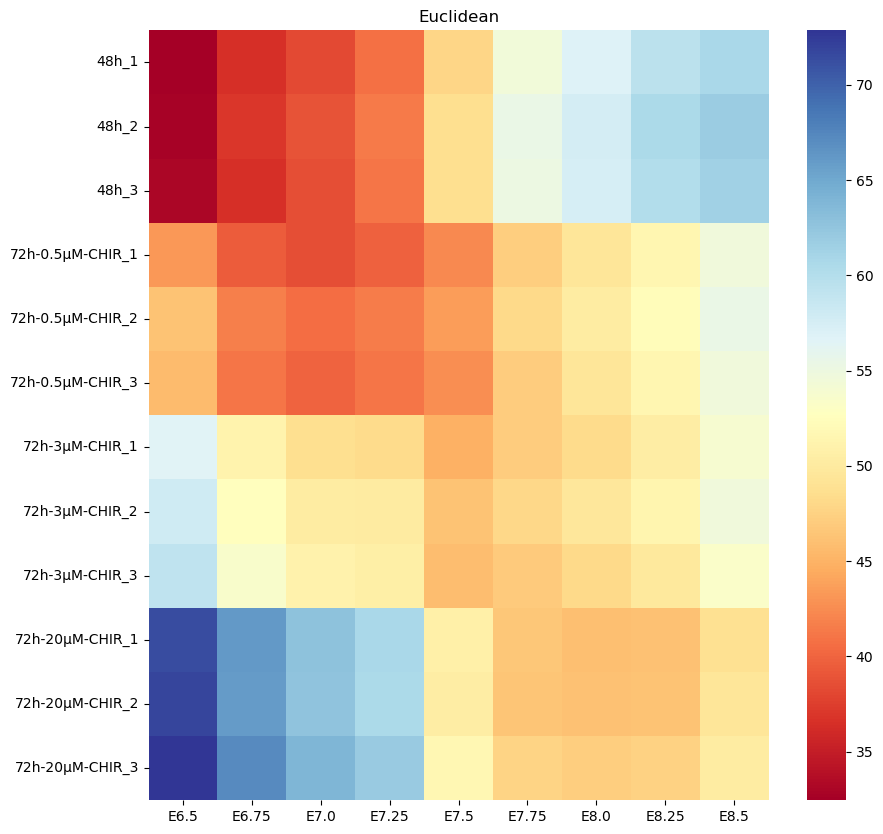

In [95]:
fig, ax = plt.subplots(1,figsize=(10,10))
sns.heatmap(d_euclidean, cmap="RdYlBu", ax=ax)
ax.set_title("Euclidean")
fig.show()

plt.savefig(f"../results/chir_conditions_analysis_heatmap_overlap.{save_format}",bbox_inches="tight",transparent=True)

## Averaged distance matrix

The same but averaged over conditions.

In [96]:
# Order to plot the bulk conditions
order = ['48h', '72h-0.5μM-CHIR', '72h-3μM-CHIR', '72h-20μM-CHIR']

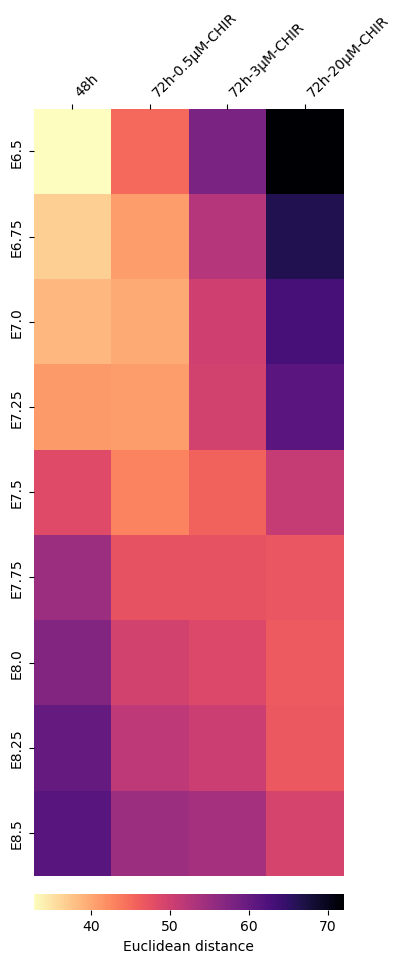

In [97]:
fig, ax = plt.subplots(1, 1, figsize=(4, 12))  # swap width and height for horizontal colorbar

# Compute grouped mean as before
d_euclidean_ = d_euclidean.groupby([i[:-2] for i in d_euclidean.index.values]).mean()
d_euclidean_ = d_euclidean_.T.groupby([i.split("_")[0] for i in d_euclidean_.columns.values]).mean().T

# Draw heatmap
sns.heatmap(
    d_euclidean_.loc[order, :].transpose(),
    cmap="magma_r",
    ax=ax,
    cbar_kws={'orientation': 'horizontal', 'label': 'Euclidean distance', 'pad':0.02}  # colorbar at bottom
)

# Move x-axis labels to top
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')  # rotate x labels


plt.savefig(f"../results/chir_conditions_analysis_heatmap_overlap_mean.{save_format}",
            bbox_inches="tight", transparent=True)
plt.show()


## Average Gene Overlap

This is a list of common genes expressed in both datasets where we can see similarities in the gene patterns by stages.

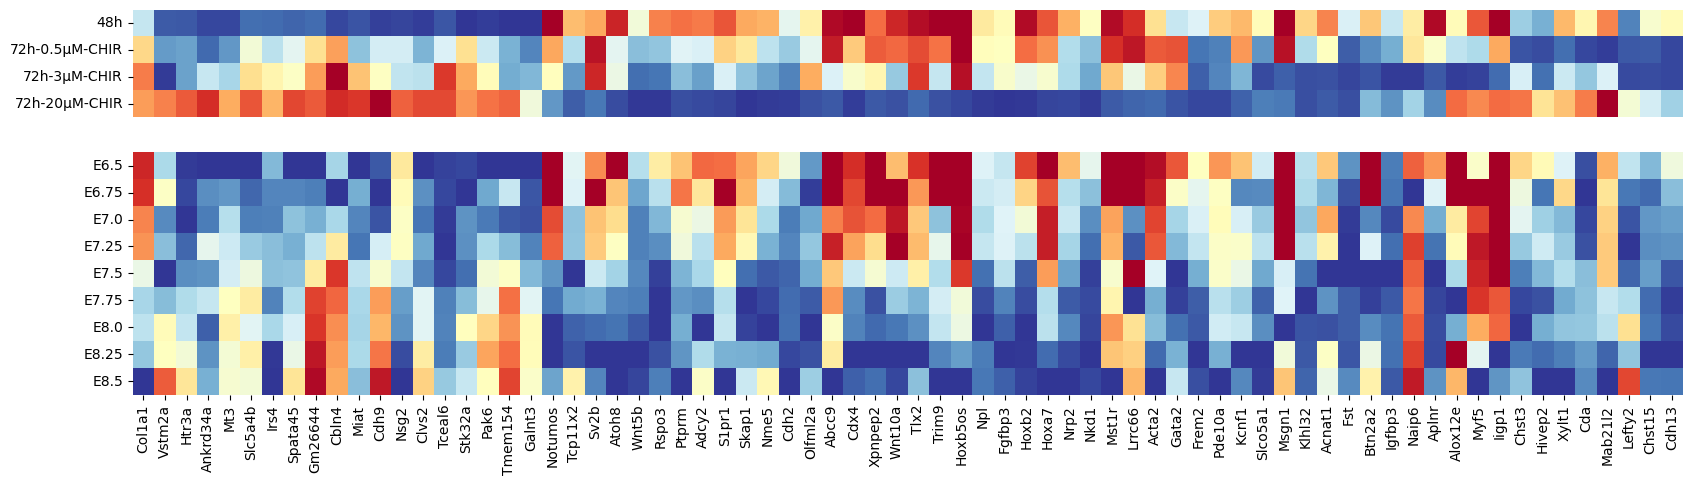

In [98]:
#This is just to generate a clustermap on the genes
l = [int(i[1:]) for i in fs.get_feature_names_out()]
names = df_gastruloid.columns.values[l]
df1_selected = pd.DataFrame(fs.transform(df_gastruloid.values),index=df1.index,columns=names)
df1_selected = df1_selected.div(df1_selected.max(axis=0),axis=1)
fig_ = sns.clustermap(df1_selected,row_cluster=False,figsize=(20,10),metric="cosine")
plt.close()

#This is to actually make the plot
t = [i.get_text() for i in fig_.ax_heatmap.get_xticklabels()]

fig,ax = plt.subplots(2,1,figsize=(20,5), gridspec_kw={'height_ratios': [4, 9]})

#Gastruloid heatmap
df1_selected = df1.loc[:,t]
df1_selected = df1_selected.div(df1_selected.max(axis=0),axis=1)
df1_selected_ = df1_selected.groupby([i[:-2] for i in df1_selected.index.values]).mean()
sns.heatmap(df1_selected_.loc[order,:], cmap="RdYlBu",ax=ax[0],cbar=False)
ax[0].set_xticks([])
ax[0].set_xticklabels([])
ax[0].set_xlabel("")

#Mouse heatmap
df2_selected = df2.loc[:,t]
df2_selected = df2_selected.div(df2_selected.max(axis=0),axis=1)
df2_selected_ = df2_selected.groupby([i.split("_")[0] for i in df2_selected.index.values]).mean()
sns.heatmap(df2_selected_,ax=ax[1], cmap="RdYlBu",cbar=False)
ax[1].set_xlabel("");

plt.savefig(f"../results/chir_conditions_analysis_heatmap_genes.{save_format}",bbox_inches="tight",transparent=True)

# Robustness analysis

In this analysis we show that, changing the parameters of the analysis, we still obtain similar results. So the analysis is robust to perturbations.

In [99]:
conditions = [
    {"variance_threshold":.5,"n_pcs":None,"metric":"euclidean"},
    {"variance_threshold":.8,"n_pcs":4,"metric":"euclidean"},
    {"variance_threshold":.8,"n_pcs":None,"metric":"euclidean"},
    {"variance_threshold":0.3,"n_pcs":13,"metric":"euclidean"},
    {"variance_threshold":.8,"n_pcs":None,"metric":"cosine"},
    {"variance_threshold":1,"n_pcs":None,"metric":"euclidean"},
    {"variance_threshold":.8,"n_pcs":13,"metric":"euclidean"},
]

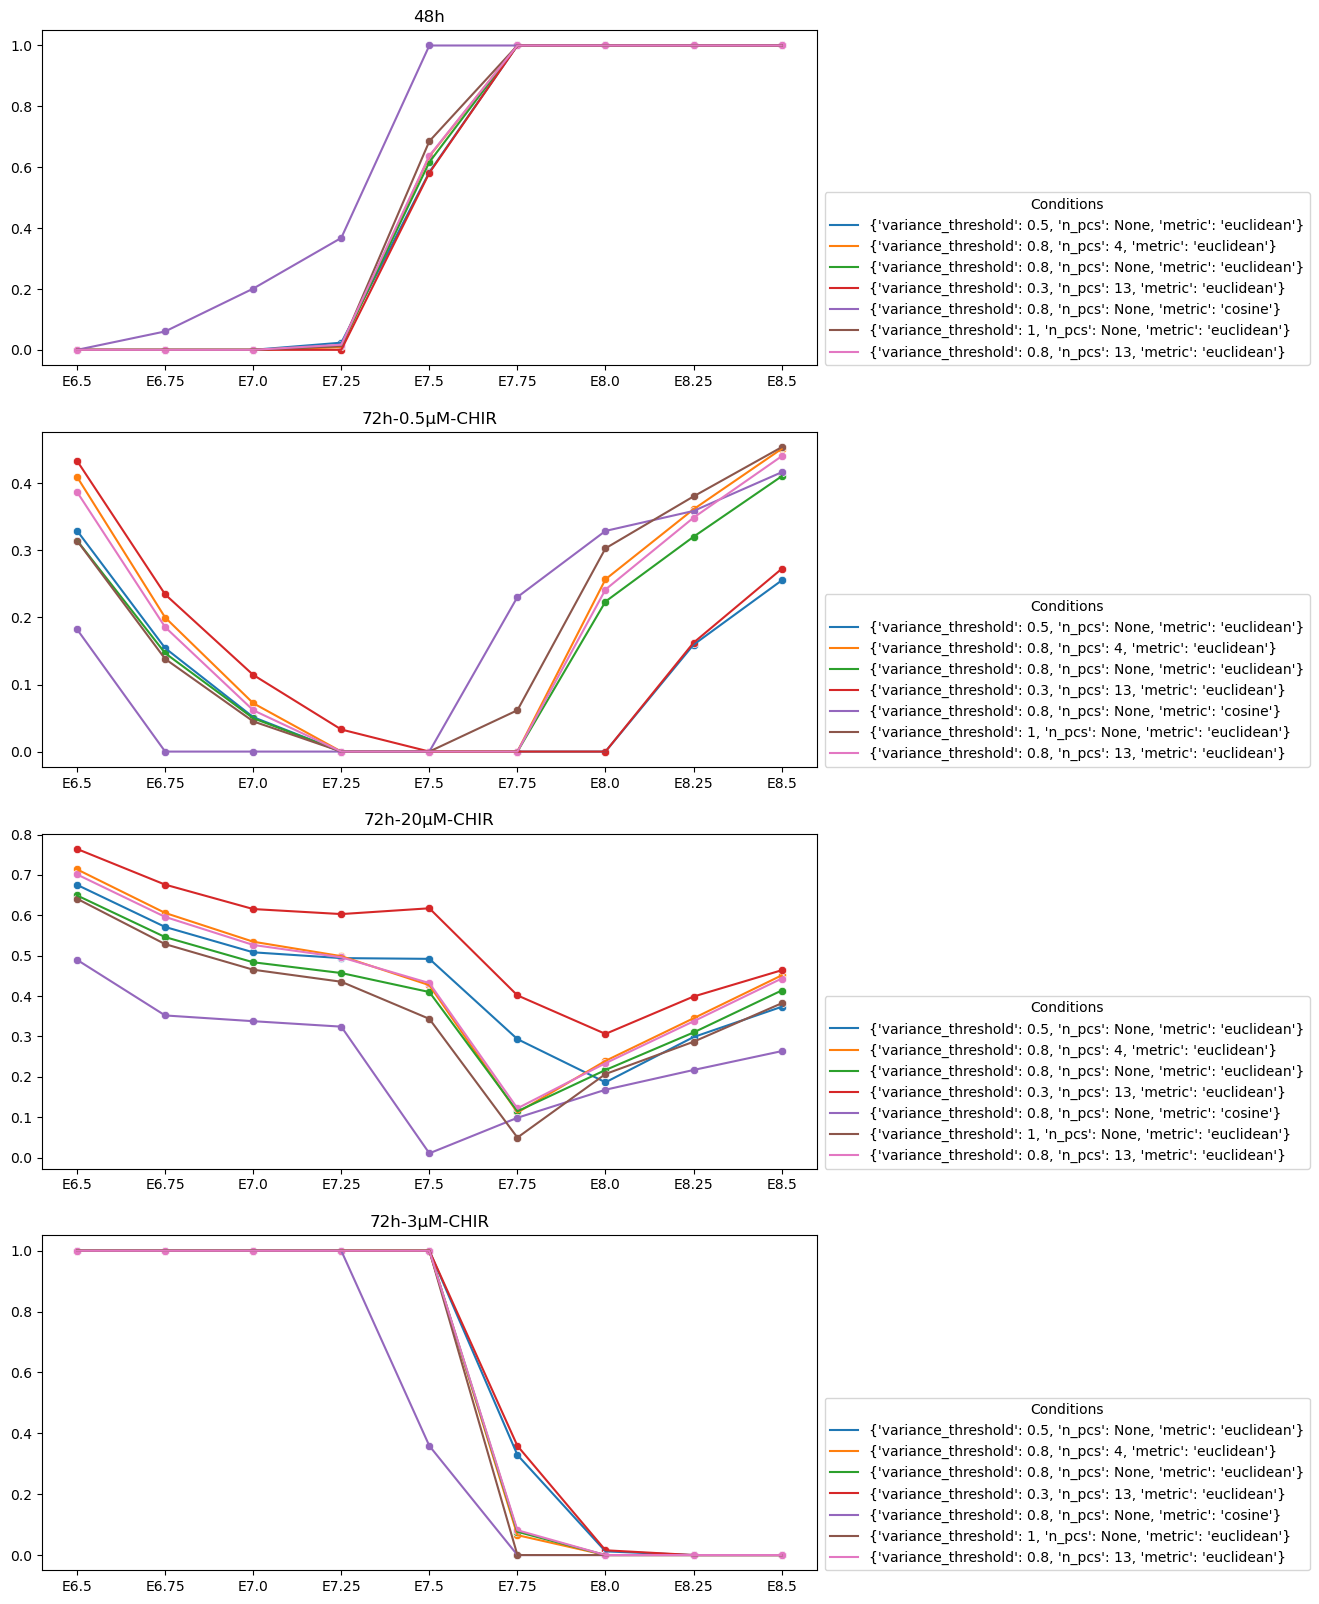

In [100]:
fig,ax = plt.subplots(4,1,figsize=(10,20))

for i in conditions:

    # Threshold
    fs_ = VarianceThreshold(threshold=i["variance_threshold"])
    fs_.fit(df1.values)
    l = [int(i[1:]) for i in fs_.get_feature_names_out()]

    df1_pca = pd.DataFrame(fs_.transform(df1.values),index=df1.index)
    df2_pca = pd.DataFrame(fs_.transform(df2.values),index=df2.index)
    
    #PCA
    if i["n_pcs"] != None:
        names = df1.columns.values[l]
        df1_fs = pd.DataFrame(fs_.transform(df1.values),index=df1.index,columns=names)
        pca = PCA(n_components=min(i["n_pcs"],df1_fs.shape[0]-1))
        pca.fit(df1_fs.values)
        df1_pca = pd.DataFrame(pca.transform(fs_.transform(df1.values)),index=df1.index)
        df2_pca = pd.DataFrame(pca.transform(fs_.transform(df2.values)),index=df2.index)

    d_euclidean,m_euclidean = distance_table(df1_pca,df2_pca,metric=i["metric"])
    
    d_euclidean_ = d_euclidean.groupby([i[:-2] for i in d_euclidean.index.values]).mean()
    d_euclidean_ = d_euclidean_.T.groupby([i.split("_")[0] for i in d_euclidean_.columns.values]).mean().T

    for j,k in enumerate(order):
        y = (d_euclidean_.loc[k,:]-d_euclidean_.min())/(d_euclidean_.max()-d_euclidean_.min())
        sns.lineplot(x=d_euclidean_.columns.values,y=y,ax=ax[j],label=i)
        sns.scatterplot(x=d_euclidean_.columns.values,y=y,ax=ax[j])

for i,j in enumerate(d_euclidean_.index.values):
    ax[i].legend(loc=(1.01,0),title="Conditions")
    ax[i].set_ylabel("")
    ax[i].set_title(j)

plt.savefig(f"../results/chir_conditions_analysis_robustness.{save_format}",bbox_inches="tight",transparent=True)

# PCA analysis

In [101]:
fs = VarianceThreshold(threshold=1)
fs.fit(df1.values)

print("Retained: ",len(fs.get_feature_names_out()))

Retained:  503


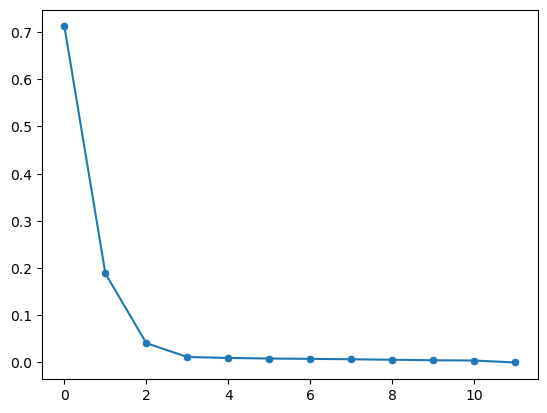

In [102]:
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index)
pca = PCA(n_components=12)
pca.fit(df1_fs.values)

sns.lineplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)
sns.scatterplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)

plt.savefig(f"../results/chir_conditions_analysis_pca_explaiden_variance.{save_format}",bbox_inches="tight",transparent=True)

In [103]:
names = df1.columns.values[[int(i[1:]) for i in fs.get_feature_names_out()]]
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=names)
pca = PCA(n_components=min(3,df1.shape[0]-1))
pca.fit(fs.transform(df1.values));

## Representation

Show the PCA components and the Pijuan-Sala projection. The PCA captures time evolution.

In [104]:
df1.index.str.split('_')[:][0]

['48h', '1']

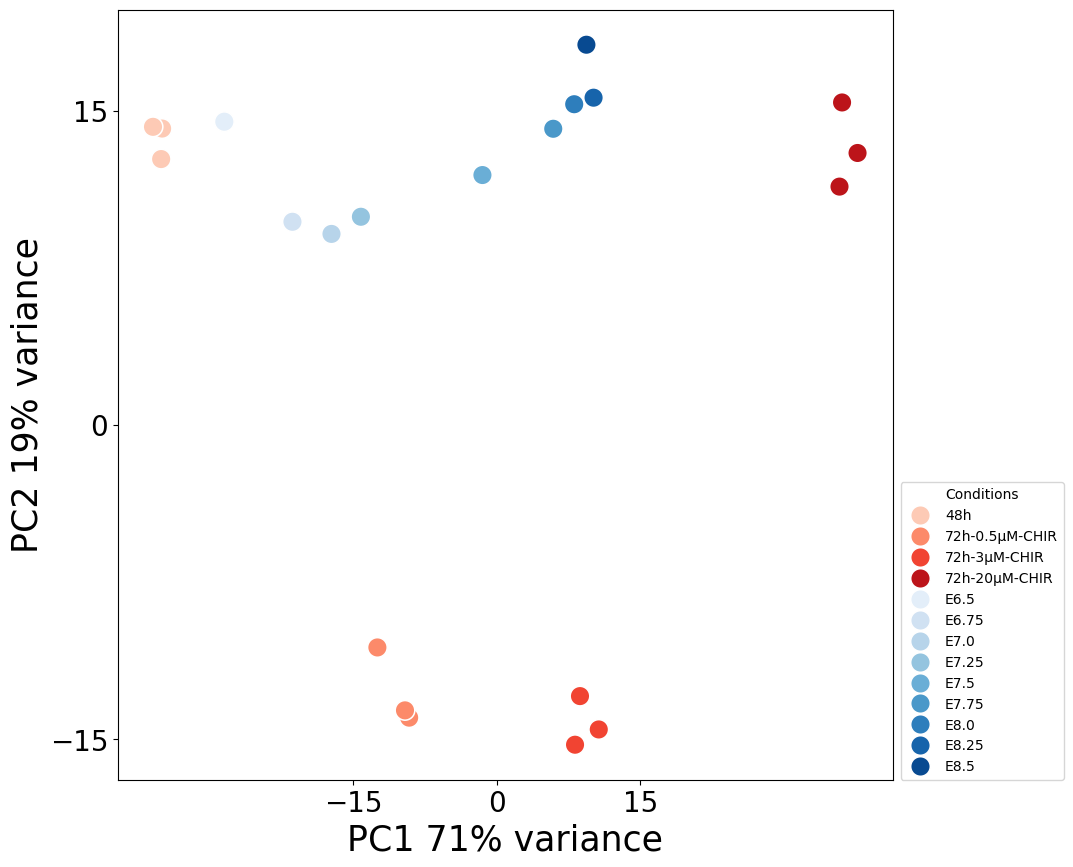

In [105]:
fig,ax = plt.subplots(figsize=(10,10))
conditions = [idx.rsplit('_', 1)[0] for idx in df_gastruloid.index]
x = pca.transform(fs.transform(df1.values))
p = sns.scatterplot(x=x[:,0],y=x[:,1],
                hue=conditions,
                s=200,palette="Reds")

x = pca.transform(fs.transform(df2.values))
df_embryo_ = pd.DataFrame(x,index=df2.index.values).groupby([i.split("_")[0] for i in df2.index.values]).mean()
p2 = sns.scatterplot(x=df_embryo_.values[:,0],y=df_embryo_.values[:,1],hue=[i for i in df_embryo_.index.values],marker="o",palette="Blues",s=200)

# axes
plt.xlabel(f'PC1 {int(np.round(pca.explained_variance_ratio_[0]*100,decimals=0))}% variance', fontsize=25)
plt.ylabel(f'PC2 {int(np.round(pca.explained_variance_ratio_[1]*100,decimals=0))}% variance', fontsize=25)

#
ax.set_xticks([-15,0, 15])
plt.xticks(fontsize=20)
ax.set_yticks([-15,0, 15])
plt.yticks(fontsize=20)
#ax.invert_xaxis()
#ax.invert_yaxis()

#legend
ax.legend(loc=(1.01,0),title="Conditions")

plt.savefig(f"../results/chir_conditions_analysis_scatterplot.{save_format}",bbox_inches="tight",transparent=True)

## Loadings

This shows that buttom-left to up-right is capturing changes in genes like (T, Wnt3a, etc.) and up-left to bottom-right capturing expressioon of genes like (Hox-family).

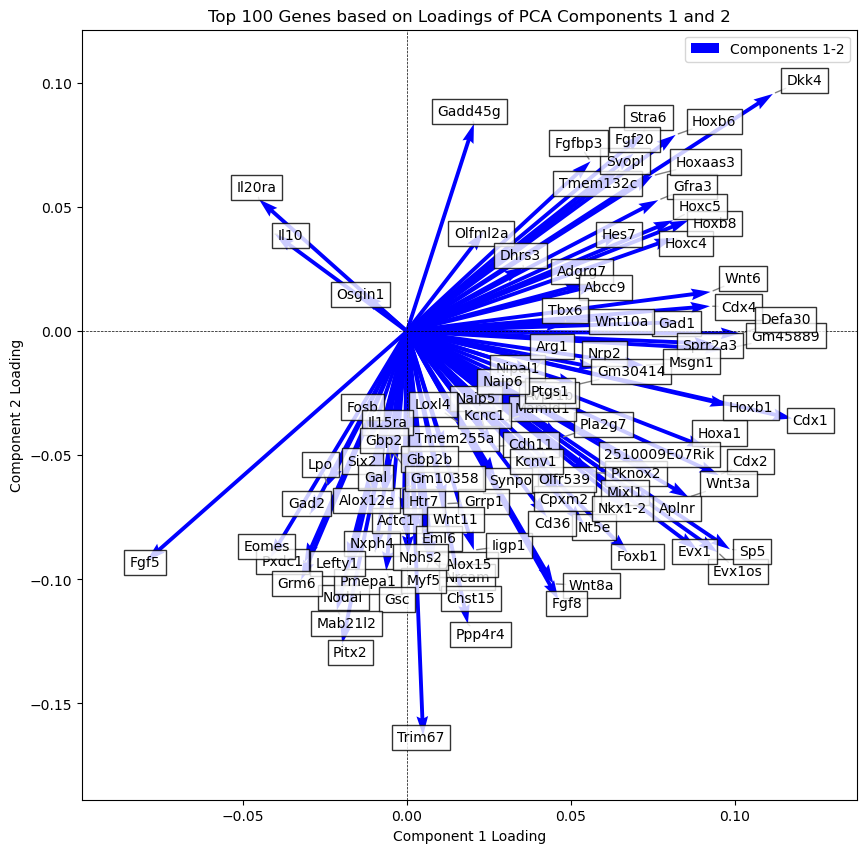

In [106]:
fig,ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,100,ax)

plt.savefig(f"../results/chir_conditions_analysis_heatmap_loadings.{save_format}",bbox_inches="tight",transparent=True)